In [107]:
import numpy as np
import matplotlib.pyplot as plt

In [108]:
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
from scipy.integrate import trapezoid

from numpy.random import normal, uniform

import tqdm

import random
from random import randint

import torch
import torch.nn as nn
import torch.fft as fft

import math

import random
import jax
import jax.numpy as jnp
from jax import vmap


In [109]:
def random_smooth_field_2d_numpy(Nx, modes=8):
    freq = np.zeros((Nx, Nx), dtype=np.complex64)

    for i in range(-modes, modes+1):
        for j in range(-modes, modes+1):
            freq_i = i % Nx
            freq_j = j % Nx
            amplitude = np.random.randn() * (1.0 / (1 + i*i + j*j))
            phase = 1 * np.pi * np.random.rand()
            cval = amplitude * np.exp(1j * phase)
            freq[freq_i, freq_j] = cval

    field_complex = np.fft.ifft2(freq)
    field_real = field_complex.real

    # Normalize to [0,1]
    field_real -= field_real.min()
    field_real /= (field_real.max() - field_real.min() + 1e-8)

    return field_real

# Generate multiple fields
num_samples = 100
Nx = 32
N_int = Nx-2

N = Nx**2
N_domain_tot = N_int**2
N_boundary_tot = N-N_domain_tot

samples_np = [random_smooth_field_2d_numpy(Nx) for _ in range(num_samples)]


In [110]:
# Run the Navier-Stokes simulation from each of the generated initial conditions
simulated_fields = []

# Domain parameters
L = 1*np.pi        # Domain length
dt = 0.01            # Time step
T = 5.0              # Final time
viscosity = 1e-3     # Kinematic viscosity
steps = int(T / dt)  # Number of time steps

# Create grid
x = np.linspace(0, L, Nx, endpoint=False)
y = np.linspace(0, L, Nx, endpoint=False)
kx = np.fft.fftfreq(Nx, d=L/Nx) * 1 * np.pi
ky = np.fft.fftfreq(Nx, d=L/Nx) * 1 * np.pi
kx, ky = np.meshgrid(kx, ky)
k_squared = kx**2 + ky**2
k_squared[0, 0] = 1.0  # avoid division by zero in stream function calc

# Initial vorticity (Taylor-Green vortex)
X, Y = np.meshgrid(x, y)

grid = np.concatenate((X.flatten()[:,None],Y.flatten()[:,None]),axis=1)

boundary_mask = (X == x[0]) | (X == x[-1]) | (Y == y[0]) | (Y == y[-1])
# Flatten the mask
boundary_indices = np.where(boundary_mask.flatten())[0]

snapshot_interval = 1

num_snapshots = int(steps/snapshot_interval)

# Separate boundary points and interior points
boundary_points = grid[boundary_indices]
interior_points = np.delete(grid, boundary_indices, axis=0)

# Rearrange grid with boundary points at the bottom
rearranged_grid = np.concatenate((interior_points, boundary_points), axis=0)

# Convert to torch tensor to obtain indices of interior points
interior_mask = ~boundary_mask.flatten()
interior_indices = np.where(interior_mask)[0]

#Interior indices, then boundary indices
rearranged_indices = np.concatenate((interior_indices,boundary_indices),axis=0)

solutions = np.zeros((N,num_snapshots,num_samples))
solutions_dx = np.zeros((N_domain_tot,num_snapshots,num_samples))
solutions_dy = np.zeros((N_domain_tot,num_snapshots,num_samples))
solutions_Lap = np.zeros((N_domain_tot,num_snapshots,num_samples))
solutions_psi = np.zeros((N,num_snapshots,num_samples))

j = 0
for initial_omega in samples_np:
    omega = initial_omega.copy()
    for r in range(steps):
        omega_hat = np.fft.fft2(omega)
        psi_hat = -omega_hat / k_squared
        psi = np.fft.ifft2(psi_hat).real

        # Velocity field (u, v)
        u = np.fft.ifft2(1j * ky * psi_hat).real
        v = -np.fft.ifft2(1j * kx * psi_hat).real

        # Nonlinear convection term
        d_omega_dx = np.fft.ifft2(1j * kx * omega_hat).real
        d_omega_dy = np.fft.ifft2(1j * ky * omega_hat).real
        convection = u * d_omega_dx + v * d_omega_dy

        # Diffusion term
        diffusion = viscosity * np.fft.ifft2(-k_squared * omega_hat).real
        if r % snapshot_interval == 0:
            solutions[:,int(r/snapshot_interval),j] = omega.flatten()[rearranged_indices]
            solutions_dx[:,int(r/snapshot_interval),j] = d_omega_dx[1:-1,1:-1].flatten()
            solutions_dy[:,int(r/snapshot_interval),j] = d_omega_dy[1:-1,1:-1].flatten()
            solutions_Lap[:,int(r/snapshot_interval),j] = (diffusion[1:-1,1:-1]/viscosity).flatten()
            solutions_psi[:,int(r/snapshot_interval),j] = psi.flatten()[rearranged_indices]

        # Update
        omega += dt * (-convection + diffusion)
    j = j+1

    simulated_fields.append(omega)

In [ ]:
solutions_stack = np.vstack([solutions, solutions_dx, solutions_dy, solutions_Lap])
steps = int(T / dt)  # Number of time steps

burnin = 70

K_omega = np.einsum('ikl,jkl->ij',solutions_stack[:,burnin::10,:],solutions_stack[:,burnin::10,:])/(num_samples*steps)

In [ ]:
#K_omega_lin = K_omega

In [6]:
from scipy.special import kv, gamma  # Bessel and Gamma functions

def matern_kernel(A, nu=2.5, length_scale=1.0, sigma=1.0):
    """
    Compute the Matérn kernel matrix for a tensor A of shape (M, T, N).

    Parameters
    ----------
    A : ndarray, shape (M, T, N)
        Tensor containing M samples of size (T, N).
    nu : float
        Smoothness parameter (common values: 0.5, 1.5, 2.5).
    length_scale : float
        Length scale parameter ℓ.
    sigma : float
        Output scale (overall variance).

    Returns
    -------
    K : ndarray, shape (M, M)
        Matérn kernel matrix.
    """
    M, T, N = A.shape
    X = A.reshape(M, T*N)  # flatten each sample

    # Compute pairwise Euclidean distances
    sq_norms = np.sum(X**2, axis=1, keepdims=True)
    D2 = sq_norms + sq_norms.T - 2 * X @ X.T
    R = np.sqrt(np.maximum(D2, 0.0))

    # Avoid division by zero on the diagonal
    R[R == 0] = 1e-12

    # Matérn kernel formula
    sqrt_term = np.sqrt(2 * nu) * R / length_scale
    coef = sigma**2 * (2**(1 - nu)) / gamma(nu)
    K = coef * (sqrt_term**nu) * kv(nu, sqrt_term)

    # For r = 0, limit k(r) = sigma^2
    np.fill_diagonal(K, sigma**2)
    return K

In [7]:
def cubic_poly_kernel(A, c=1.0):
    """
    Compute K_ij = ( <A[i,:,:], A[j,:,:]> + c )^3
    for A of shape (M, T, N).
    
    Returns:
        K : (M, M) kernel matrix
    """
    M, T, N = A.shape
    
    # Flatten each (T, N) slice into a vector
    X = A.reshape(M, T*N)  # shape (M, T*N)
    
    # Compute pairwise dot products
    G = X @ X.T             # (M, M)
    
    # Apply cubic polynomial kernel
    K = (G + c)**3
    d = np.sqrt(np.diag(K))
    return K/np.outer(d,d)

In [8]:
def frob_kernel(A, sigma):
    """
    Compute K_ij = exp(-||A[i,:,:] - A[j,:,:]||_F^2 / (2*N*T*sigma**2))
    for A of shape (M, T, N).
    Returns K of shape (M, M).
    """
    M, T, N = A.shape
    
    # Flatten each (T, N) slice into a single vector of length T*N
    X = A.reshape(M, T*N)          # shape (M, T*N)
    
    # Compute pairwise squared Euclidean distances
    sq_norms = np.sum(X**2, axis=1, keepdims=True)  # (M, 1)
    D2 = sq_norms + sq_norms.T - 2 * X @ X.T        # (M, M)
    
    # Gaussian kernel
    K = np.exp(-D2 / (2 * N * T * sigma**2))
    return K

In [ ]:
#K_omega = cubic_poly_kernel(solutions_stack[:,:,:],2.5)/(num_samples*num_snapshots)

In [9]:
np.outer(np.sqrt(np.diag(K_omega)),np.sqrt(np.diag(K_omega)))

array([[0.02691091, 0.02659958, 0.02625436, ..., 0.11630441, 0.11303008,
        0.11347546],
       [0.02659958, 0.02629185, 0.02595062, ..., 0.11495888, 0.11172244,
        0.11216267],
       [0.02625436, 0.02595062, 0.02561382, ..., 0.1134669 , 0.11027245,
        0.11070697],
       ...,
       [0.11630441, 0.11495888, 0.1134669 , ..., 0.502648  , 0.48849691,
        0.49042177],
       [0.11303008, 0.11172244, 0.11027245, ..., 0.48849691, 0.47474422,
        0.47661489],
       [0.11347546, 0.11216267, 0.11070697, ..., 0.49042177, 0.47661489,
        0.47849293]], shape=(3724, 3724))

In [10]:
#psi_stack = torch.vstack([solutions_psi,-solutions[interior_indices,:,:]])
#K_psi = np.einsum('ikl,jkl->ij',psi_stack,psi_stack)/(N*num_samples)

In [11]:
def maximin(x):
  init_indices = np.arange(len(x[:,0]))[:,None]

  x = np.concatenate((x,init_indices),axis=1)
  indices = np.copy(init_indices)

  #Select arbitrary index to start (here 0)
  indices[0] = 0
  A = x[indices[0],:-1]

  x = np.delete(x,indices[0],axis=0)

  for i in range(1,len(indices)):
    maximizer = np.argmax(cdist(x[:,:-1],A).min(axis=1))
    indices[i] =x[int(maximizer),:][2]
    A = np.vstack([A,x[int(maximizer),:-1]])
    x = np.delete(x,int(maximizer),axis=0)

  return indices.reshape(-1)

#Permutation map

P_omega = np.zeros(3*N_domain_tot+N)
P_omega[:N] = maximin(grid).astype(int)

#Identity map for derivative measurements
ord = np.arange(N_domain_tot)
P_omega[N:] = np.hstack([ord,ord,ord])

P_psi = np.zeros(N_domain_tot+N)
P_psi[:N] = maximin(grid).astype(int)
P_psi[N:] = ord

#Lengthscale of x
def lengthscale(x):
  lengths = np.ones(len(x[:,0]))
  lengths[0] = float('inf')

  for i in range(1,len(x[:,0])):
    lengths[i] = np.min(cdist(np.array([x[i,:]]),x[:i,:]))

  return lengths

grid_reordered = grid[maximin(grid)]

In [12]:
#Define 2D Matern kernel and derivatives
def kernel_matern(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)  
  K = (1+jnp.sqrt(5)*r/sigma+5/3*r**2/sigma**2)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_dx1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(x1-y1)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r)
  return K

def kernel_matern_dy1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(y1-x1)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r)
  return K

def kernel_matern_dx2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(x2-y2)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r)
  return K

def kernel_matern_dy2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(y2-x2)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r)
  return K

def kernel_matern_dx1dy1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  #K = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(-jnp.sqrt(5)/sigma*(x1-y1)*(y1-x1)+sigma*jnp.sqrt(5)*r)
  K = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(5*(x1-y1)**2/sigma-sigma-jnp.sqrt(5)*r)
  return K

def kernel_matern_dx1dy2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(y1-x1)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(-5/sigma*(y2-x2))
  return K

def kernel_matern_dx2dy2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  #K = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(-jnp.sqrt(5)/sigma*(x2-y2)*(y2-x2)+sigma*jnp.sqrt(5)*r)
  K = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(5*(x2-y2)**2/sigma-sigma-jnp.sqrt(5)*r)
  return K

def kernel_matern_dx2dy1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(y2-x2)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(-5/sigma*(y1-x1))
  return K

def kernel_matern_Lap_x(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K_x1x1 = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r-5*(x1-y1)**2/sigma)
  K_x2x2 = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r-5*(x2-y2)**2/sigma)
  K = K_x1x1+K_x2x2

  return K

def kernel_matern_Lap_x_dy1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = 25*jnp.sqrt(5)/(3*sigma**4)*(y1-x1)*(4-jnp.sqrt(5)*r/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_Lap_x_dy2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = 25*jnp.sqrt(5)/(3*sigma**4)*(y2-x2)*(4-jnp.sqrt(5)*r/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)

  return K

def kernel_matern_Lap_y(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K_y1y1 = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r-5*(x1-y1)**2/sigma)
  K_y2y2 = -5/(3*sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)*(sigma+jnp.sqrt(5)*r-5*(x2-y2)**2/sigma)
  K = K_y1y1+K_y2y2
  return K

def kernel_matern_Lap_y_dx1(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = 25*jnp.sqrt(5)/(3*sigma**4)*(x1-y1)*(4-jnp.sqrt(5)*r/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_Lap_y_dx2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = 25*jnp.sqrt(5)/(3*sigma**4)*(x2-y2)*(4-jnp.sqrt(5)*r/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_Lap_xy(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(35*jnp.sqrt(5)*r/sigma**2-40/sigma-25*r**2/sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def K_Matern(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))

  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dy1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dy1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))


  return K_matrix

def K_Matern_dy2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dy2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx1dy1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx1dy1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx1dy2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx1dy2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx2dy1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx2dy1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_dx2dy2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_dx2dy2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix


def K_Matern_Lap_y(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_y(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_x(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_x(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_xy(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_xy(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_x_dy1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_x_dy1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_x_dy2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_x_dy2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_y_dx1(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_y_dx1(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix

def K_Matern_Lap_y_dx2(U,V,sigma=0.3):
  size = len(U[:,0])
  size2 = len(V[:,0])
  X0=jnp.transpose(jnp.tile(U[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(U[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(V[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(V[:,1],(size,1)))


  val = vmap(lambda x1, y1, x2, y2: kernel_matern_Lap_y_dx2(x1,y1,x2,y2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))

  return K_matrix


In [13]:
sigma = 2
K_Mat = jnp.zeros((N+3*N_domain_tot,N+3*N_domain_tot))
K_Mat = K_Mat.at[:N,:N].set(K_Matern(rearranged_grid,rearranged_grid,sigma))
K_Mat = K_Mat.at[:N,N:N+N_domain_tot].set(K_Matern_dy1(rearranged_grid,interior_points,sigma))
K_Mat = K_Mat.at[:N,N+N_domain_tot:N+2*N_domain_tot].set(K_Matern_dy2(rearranged_grid,interior_points,sigma))
K_Mat = K_Mat.at[:N,N+2*N_domain_tot:N+3*N_domain_tot].set(K_Matern_Lap_y(rearranged_grid,interior_points,sigma))
K_Mat = K_Mat.at[N:N+N_domain_tot,:N].set(K_Matern_dx1(interior_points,rearranged_grid,sigma))
K_Mat = K_Mat.at[N+N_domain_tot:N+2*N_domain_tot,:N].set(K_Matern_dx2(interior_points,rearranged_grid,sigma))
K_Mat = K_Mat.at[N+2*N_domain_tot:N+3*N_domain_tot,:N].set(K_Matern_Lap_x(interior_points,rearranged_grid,sigma))
K_Mat = K_Mat.at[N:N+N_domain_tot,N:N+N_domain_tot].set(K_Matern_dx1dy1(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N:N+N_domain_tot,N+N_domain_tot:N+2*N_domain_tot].set(K_Matern_dx1dy2(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N:N+N_domain_tot,N+2*N_domain_tot:N+3*N_domain_tot].set(K_Matern_Lap_y_dx1(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+N_domain_tot:N+2*N_domain_tot,N:N+N_domain_tot].set(K_Matern_dx2dy1(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+N_domain_tot:N+2*N_domain_tot,N+N_domain_tot:N+2*N_domain_tot].set(K_Matern_dx2dy2(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+N_domain_tot:N+2*N_domain_tot,N+2*N_domain_tot:N+3*N_domain_tot].set(K_Matern_Lap_y_dx2(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+2*N_domain_tot:N+3*N_domain_tot,N:N+N_domain_tot].set(K_Matern_Lap_x_dy1(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+2*N_domain_tot:N+3*N_domain_tot,N+N_domain_tot:N+2*N_domain_tot].set(K_Matern_Lap_x_dy2(interior_points,interior_points,sigma))
K_Mat = K_Mat.at[N+2*N_domain_tot:N+3*N_domain_tot,N+2*N_domain_tot:N+3*N_domain_tot].set(K_Matern_Lap_xy(interior_points,interior_points,sigma))


In [14]:
K_Empirical = K_omega

In [ ]:
#Theta_psi = np.zeros((N+N_domain_tot,N+N_domain_tot))
#Theta_psi[:N, :N] = K_psi[P_psi[:N].astype(int)][:, P_psi[:N].astype(int)]
#Theta_psi[N:, N:] = K_psi[N:, N:]
#Theta_psi[N:, :N] = K_psi[N:, P_psi[:N].astype(int)]
#Theta_psi[:N, N:] = Theta_psi[N:, :N].T

Theta_omega = np.zeros((N+3*N_domain_tot,N+3*N_domain_tot))

Theta_omega[:N, :N] = K_Empirical[P_omega[:N].astype(int)][:, P_omega[:N].astype(int)]
Theta_omega[N:, N:] = K_Empirical[N:, N:]
Theta_omega[N:, :N] = K_Empirical[N:, P_omega[:N].astype(int)]

Theta_omega[:N, N:] = Theta_omega[N:, :N].T

trace1 = np.trace(Theta_omega[:N, :N])
trace2 = np.trace(Theta_omega[N:N + N_domain_tot, N:N + N_domain_tot])
trace3 = np.trace(Theta_omega[N + N_domain_tot:N + 2 * N_domain_tot, N + N_domain_tot:N + 2 * N_domain_tot])
trace4 = np.trace(Theta_omega[N + 2*N_domain_tot:N + 3 * N_domain_tot, N + 2*N_domain_tot:N + 3 * N_domain_tot])

ratio = trace2 / trace1
ratio2 = trace3 / trace1
ratio3 = trace4 / trace1

nugget = 1e-3

temp_w = np.concatenate((np.ones((1, N)),
                       ratio * np.ones((1, N_domain_tot)),
                       ratio2 * np.ones((1, N_domain_tot)), ratio3 * np.ones((1, N_domain_tot))), axis=1)
Theta_omega = Theta_omega + nugget * np.diag(temp_w[0])


In [ ]:
# -----------------------------
l = lengthscale(grid_reordered)  # lengthscale should return a numpy array
l_omega = np.hstack([l, l[-1] * np.ones(3 * N_domain_tot)])
l_psi = np.hstack([l, l[-1] * np.ones(N_domain_tot)])

# -----------------------------
# 3) Sparsity set functions
# -----------------------------
def sparsity_set(x, rho):
    # Reorder x according to maximin(x)
    x = x[maximin(x)]
    dist = cdist(x, x)
    # Broadcast the lengthscale computed from x to a full matrix.
    rhol = rho * np.broadcast_to(lengthscale(x), (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

def sparsity_extended(x, rho,P, l):
    # extender: indices from P[N:] cast to int
    extender = x[P[N:].astype(int)]
    x = x[maximin(x)]
    x = np.vstack([x, extender])
    dist = cdist(x, x)
    rhol = rho * np.broadcast_to(l, (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

# -----------------------------
# 4) Sparsity parameter rho and computing sparsity set S
# -----------------------------
rho_omega = 0.5
rho_psi = 1

S_omega = sparsity_extended(grid, rho_omega,P_omega,l_omega)
#S_psi = sparsity_extended(grid, rho_psi,P_psi,l_psi)

def card(j,S):
    s_j = S[S[:, 1] == j][:, 0]
    cardinality = len(s_j)
    return s_j, cardinality

U_omega = np.zeros((N + 3 * N_domain_tot, N + 3 * N_domain_tot))

for j in tqdm.tqdm(range(N + 3 * N_domain_tot)):
    #Use np.ix_ to index rows and columns from s_j
    s_j, _ = card(j,S_omega)
    Theta_redux = np.linalg.inv(Theta_omega[np.ix_(s_j, s_j)])
    denom = np.sqrt(Theta_redux[-1, -1])
    U_omega[s_j, j] = Theta_redux[:, -1] / denom


100%|██████████| 3724/3724 [00:00<00:00, 21583.91it/s]


In [31]:
np.max(U_omega)

np.float64(12.737755706971381)

In [32]:
#Putting all the pieces together
Permute_omega = np.zeros((N+3*N_domain_tot,N+3*N_domain_tot))

combo_omega = np.concatenate((P_omega[:N].astype(int)[:,None],np.arange(N).astype(int)[:,None]),axis=1)

Permute_omega[combo_omega[:,1],combo_omega[:,0]] = 1

Permute_omega[N:,N:] = np.eye(3*N_domain_tot)

#K_inv_red = Permute.T@U@U.T@Permute

L_omega = U_omega.T@Permute_omega

In [33]:
# #Putting all the pieces together
# Permute_psi = np.zeros((N+N_domain_tot,N+N_domain_tot))

# combo_psi = np.concatenate((P_psi[:N].astype(int)[:,None],np.arange(N).astype(int)[:,None]),axis=1)

# Permute_psi[combo_psi[:,1],combo_psi[:,0]] = 1

# Permute_psi[N:,N:] = np.eye(N_domain_tot)

# K_inv_red = Permute_psi.T@U_psi@U_psi.T@Permute_psi

# L_psi = U_psi.T@Permute_psi

In [34]:
triel_omega = L_omega.shape[0]*(L_omega.shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part of the vorticity kernel is {np.count_nonzero(L_omega)/triel_omega}")

# triel_psi = L_psi.shape[0]*(L_psi.shape[0]+1)/2
# print(f"The proportion of nonzero entries in the lower triangular part of the streamfunction kernel is {np.count_nonzero(L_psi)/triel_psi}")

The proportion of nonzero entries in the lower triangular part of the vorticity kernel is 0.0013154650768820422


In [35]:
#Check L_ROM does not contain inf values
if np.max(L_omega)==(np.inf or np.nan):
    print("Pick a higher regularization term for empirical kernel matrix for vorticity")
else:
    print("The empirical kernel for vorticity is ready to use")

# #Check L_ROM does not contain inf values
# if np.max(L_psi)==(np.inf or np.nan):
#    print("Pick a higher regularization term for empirical kernel matrix for streamfunction")
# else:
#    print("The empirical kernel for streamfunction is ready to use")

The empirical kernel for vorticity is ready to use


In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

L_omega_dense = torch.from_numpy(L_omega).float().to(device)
indices = torch.nonzero(L_omega_dense, as_tuple=False).t()
values = L_omega_dense[indices[0], indices[1]]
L_omega_sparse = torch.sparse_coo_tensor(indices, values, L_omega_dense.size(), device=device)
L_omega_sparse = L_omega_sparse.coalesce()

#L_psi_dense = torch.from_numpy(L_psi).float().to(device)
#indices = torch.nonzero(L_psi_dense, as_tuple=False).t()
#values = L_psi_dense[indices[0], indices[1]]
#L_psi_sparse = torch.sparse_coo_tensor(indices, values, L_psi_dense.size(), device=device)
#L_psi_sparse = L_psi_sparse.coalesce()

In [97]:
def J_w(z, bdy_g, L, y0, y1, y2, y3, u, v, dt=0.01):
    """
    Loss function J_ROM.
    v: tensor of shape (2*N_domain_tot,)
    bdy_g: tensor of shape (N_boundary_tot,)
    L: sparse matrix of shape (N_total, N_total)
    u0, u1, u2: tensors of shape (N_domain_tot,)
    """
    # Ensure inputs are float32.
    z = z.float().to(z.device)
    y0 = y0.float().to(z.device)
    y1 = y1.float().to(z.device)
    y2 = y2.float().to(z.device)
    y3 = y3.float().to(z.device)
    L = L.float().to(z.device,dtype=z.dtype)
    u = u.float().to(z.device)
    v = v.float().to(z.device)

    # Partition v.
    z0 = z[:N_domain_tot]
    z1 = z[N_domain_tot:2*N_domain_tot]
    z2 = z[2*N_domain_tot:3*N_domain_tot]
    
    z3 =  2/viscosity*((z0-y0)/dt+1/2*u*(z1+y1)+1/2*v*(y2+z2))-y3
    # Compute v2.

    # Construct vv = [v0, bdy_g, v1, v2].
    zz = torch.cat((z0, bdy_g, z1, z2, z3), dim=0)  # shape: (N_total,)
    # Multiply L (sparse) with vv.
    temp = torch.sparse.mm(L, zz.unsqueeze(1))  # shape: (N_total, 1)
    temp = temp.squeeze(1)
    return torch.dot(temp, temp)

def Hessian_w(z, L, u, v, dt=0.01):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    total_rows = N + 3 * N_domain_tot  # should equal N_total = 2999.
    mtx = torch.zeros((total_rows,3 * N_domain_tot), dtype=z.dtype, device=z.device)
    L = L.float().to(z.device,dtype=z.dtype)
    z = z.float().to(z.device)
    u = u.float().to(z.device)
    v = v.float().to(z.device)

    I = torch.eye(N_domain_tot, dtype=z.dtype, device=z.device)

    
    mtx[:N_domain_tot, :N_domain_tot] = I
    mtx[N:N+N_domain_tot, N_domain_tot:2*N_domain_tot] = I
    mtx[N+N_domain_tot:N+2*N_domain_tot,2*N_domain_tot:3*N_domain_tot] = I
    
    mtx[N+2*N_domain_tot:N+3*N_domain_tot,:N_domain_tot] = (2/viscosity) * (I/dt)
    mtx[N+2*N_domain_tot:N+3*N_domain_tot,N_domain_tot:2*N_domain_tot] =  1/viscosity*torch.diag(u)   
    mtx[N+2*N_domain_tot:N+3*N_domain_tot,2*N_domain_tot:3*N_domain_tot] = 1/viscosity*torch.diag(v)      
    
    
    S = torch.sparse.mm(L, mtx)
    return 2 * (S.t() @ S)

def J_psi(r, L,w):
    # Ensure inputs are float32.
    L = L.float().to(r.device, dtype=r.dtype)     
    r = r.float().to(r.device)
    w = w.float().to(r.device)
    # Compute v2.
    # Construct vv = [v0, bdy_g, v1, v2].
    vv = torch.cat((r, -w), dim=0)  # shape: (N_total,)
    # Multiply L (sparse) with vv.
    temp = torch.sparse.mm(L, vv.unsqueeze(1))  # shape: (N_total, 1)
    temp = temp.squeeze(1)
    return torch.dot(temp, temp)


def Hessian_psi(r, L):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    L = L.to(r.device, dtype=r.dtype)     
    r = r.to(r.device)
    total_rows = N+N_domain_tot # should equal N_total = 2999.
    mtx = torch.zeros((total_rows, N_domain_tot), dtype=r.dtype, device = r.device)

    mtx[:N_domain_tot, :N_domain_tot] = torch.eye(N_domain_tot, dtype=r.dtype, device = r.device)
    S = torch.sparse.mm(L, mtx)
    return 2 * torch.sparse.mm(S.t(),S)


def grad_J_w(z, bdy_g, L, y0,y1,y2,y3,u,v, dt=0.01):
    L = L.float().to(z.device, dtype=z.dtype)     
    z = z.float().clone().detach().requires_grad_(True)
    loss = J_w(z, bdy_g, L, y0,y1,y2,y3,u,v, dt)
    grad_vel, = torch.autograd.grad(loss, z, create_graph=False)
    return grad_vel

def grad_J_psi(r, L, w):
    L = L.float().to(r.device, dtype=r.dtype)     
    r = r.clone().detach().requires_grad_(True)
    loss = J_psi(r, L,w)
    grad_vel, = torch.autograd.grad(loss, r, create_graph=False)
    return grad_vel


In [98]:
test_init = torch.from_numpy(random_smooth_field_2d_numpy(Nx))

In [99]:
omega_fft = torch.fft.fft2(test_init)
psi_fft = -omega_fft/k_squared


/var/folders/7x/mpmr_n_96hv_7fkxygr63wg80000gn/T/ipykernel_25227/2651619231.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psi_fft = -omega_fft/k_squared


In [100]:
u = torch.fft.ifft2(1j * torch.from_numpy(ky) * psi_fft).real.flatten()[interior_indices]
v = -torch.fft.ifft2(1j * torch.from_numpy(kx) * psi_fft).real.flatten()[interior_indices]

In [101]:
d_omega_dx = torch.fft.ifft2(1j * torch.from_numpy(kx) * omega_fft).real
d_omega_dy = torch.fft.ifft2(1j * torch.from_numpy(ky) * omega_fft).real
omega_Lap = torch.fft.ifft2(-torch.from_numpy(k_squared) * omega_fft).real

In [106]:
M_t = 500
w_approx = torch.zeros((3 * N_domain_tot,M_t+1), dtype=torch.float32, device=device)
psi_approx = torch.zeros((N_domain_tot, M_t+1))
psi_approx[:,0] = psi_fft.flatten()[interior_indices]
bdy_p = psi_fft.flatten()[boundary_indices]

w_approx[:N_domain_tot,0] = test_init.flatten()[interior_indices]
w_approx[N_domain_tot:2*N_domain_tot,0] = d_omega_dx.flatten()[interior_indices]
w_approx[2*N_domain_tot:3*N_domain_tot,0] = d_omega_dy.flatten()[interior_indices]

bdy_g = test_init.flatten()[boundary_indices]

dt = 1e-2
step_size = 1

u_cur = torch.zeros(N_domain_tot)
v_cur = torch.zeros(N_domain_tot)


old_y0 = w_approx[:N_domain_tot, 0].clone()
old_y1 = w_approx[N_domain_tot:2*N_domain_tot,0].clone()
old_y2 = w_approx[2*N_domain_tot:3*N_domain_tot,0].clone()
old_y3 = omega_Lap.flatten()[interior_indices]



max_iter = 2

for i in tqdm.tqdm(range(M_t)):
    # Example data vectors u0, u1, u2 each of shape (N_domain_tot,)

    sol_w = w_approx[:,i].clone()


    #psi_grid = psi_approx[:,i].reshape(ny,nx)
    #psi_x = (psi_grid[2:, 1:-1] - psi_grid[:-2, 1:-1]) / (2 * dx)
    #psi_y = (psi_grid[1:-1, 2:] - psi_grid[1:-1, :-2]) / (2 * dy)
    
    #u_cur, v_cur = psi_y.flatten().to(device=device), -psi_x.flatten().to(device=device)
    
    for iter_step in range(1,max_iter+1):
        H_w = Hessian_w(sol_w, L_omega_sparse, u, v, dt)
        grad_w = grad_J_w(sol_w, bdy_g, L_omega_sparse, old_y0, old_y1, old_y2, old_y3, u, v, dt)
        #print(torch.sum(grad_w))
        delta_w = torch.linalg.solve(H_w, grad_w)
        sol_w_next = sol_w - step_size * delta_w
        #J_now = J_w(sol_w, bdy_g, L_omega_sparse, old_y0, old_y1, old_y2, old_y3, u, v, dt)
        #print(f'iter = {iter_step}, Gauss-Newton step size = {step_size}, J = {J_now.item()}')

    w_approx[:,i+1] = sol_w_next

    y0 = w_approx[:N_domain_tot,i+1].flatten().clone()
    y1 = w_approx[N_domain_tot:2*N_domain_tot, i+1].clone()    
    y2 = w_approx[2*N_domain_tot:3*N_domain_tot, i+1].clone()    
    y3 = 2/viscosity*((y0-old_y0)/dt+1/2*u*(y1+old_y1)+1/2*v*(y2+old_y2))-old_y3
    
    omega_grid = torch.zeros(N)
    omega_grid[boundary_indices] = bdy_g
    omega_grid[interior_indices] = w_approx[:N_domain_tot,i+1]    
    omega_fft = torch.fft.fft2(omega_grid.reshape((Nx,Nx)))
    psi_fft = -omega_fft/k_squared
    u = torch.fft.ifft2(1j * torch.from_numpy(ky) * psi_fft).real.flatten()[interior_indices]
    v = -torch.fft.ifft2(1j * torch.from_numpy(kx) * psi_fft).real.flatten()[interior_indices]

    #old_psi = psi_approx[:,i].clone().detach().float()
    #new_psi = solve_streamfunction(w_approx[:N,i].reshape((ny,nx)).cpu().detach().numpy(), old_psi.reshape((ny,nx)).cpu().detach().numpy(), obstacle, iterations=50)
    #psi_approx[:,i] = torch.from_numpy(new_psi).flatten()
    #H_psi = Hessian_psi(old_psi, L_psi_sparse)
    #w_int = w_approx[:N,i].reshape((ny,nx))[1:-1,1:-1].flatten()
    #J_now = J_psi(old_psi, L_psi_sparse,w_int)
    #grad_psi = grad_J_psi(old_psi, L_psi_sparse, w_int)
    #delta_psi = torch.linalg.solve(H_psi+10**-5*torch.eye(H_psi.shape[0]), grad_psi)
    #psi_approx[:,i] = old_psi - step_size * delta_psi

    old_y0 = y0.clone()
    old_y1 = y1.clone()
    old_y2 = y2.clone()
    old_y3 = y3.clone()   
    #correction term    
    
w_final = w_approx[:,-1]
#psi_final = psi_approx[:,-1]    

TypeError: can't assign a numpy.ndarray to a torch.FloatTensor

In [103]:
dt=1e-2
omega = test_init.clone().cpu().detach().numpy()
for r in range(int(steps)):
    omega_hat = np.fft.fft2(omega)
    psi_hat = -omega_hat / k_squared
    psi = np.fft.ifft2(psi_hat).real

    # Velocity field (u, v)
    u = np.fft.ifft2(1j * ky * psi_hat).real
    v = -np.fft.ifft2(1j * kx * psi_hat).real

    # Nonlinear convection term
    d_omega_dx = np.fft.ifft2(1j * kx * omega_hat).real
    d_omega_dy = np.fft.ifft2(1j * ky * omega_hat).real
    convection = u * d_omega_dx + v * d_omega_dy

    # Diffusion term
    diffusion = viscosity * np.fft.ifft2(-k_squared * omega_hat).real
    # Update
    omega += dt * (-convection + diffusion)

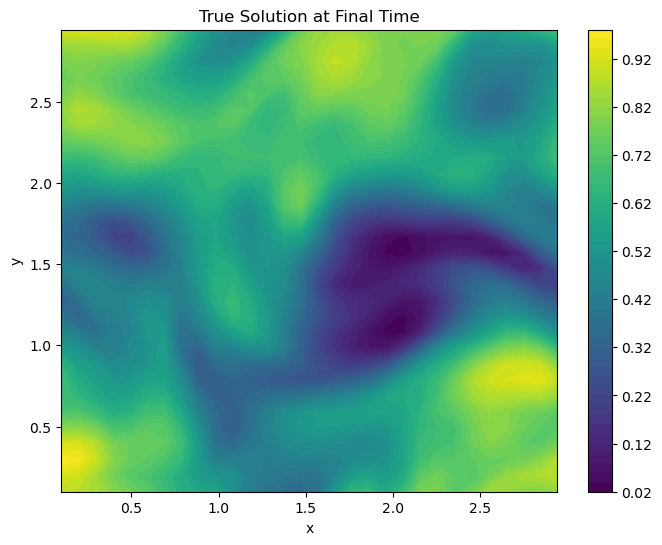

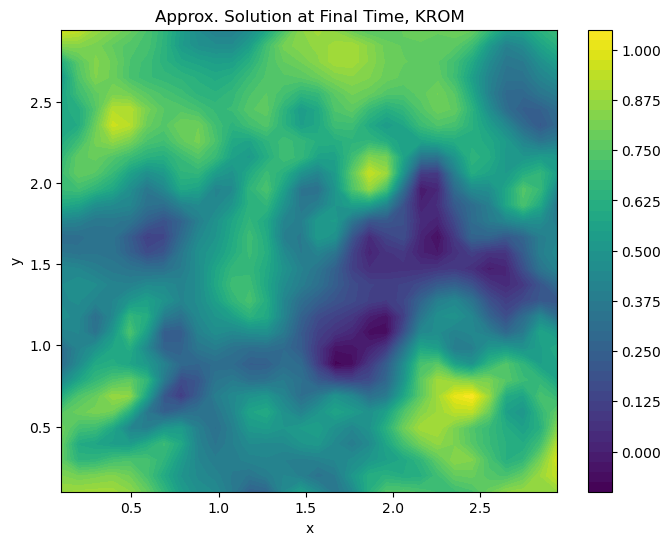

In [104]:
plt.figure(figsize=(8, 6))
X_int, Y_int = np.meshgrid(x[1:-1],y[1:-1])

w_true_final = omega[1:-1,1:-1].reshape(Nx-2,Nx-2)
# Use contourf or pcolormesh to display the 2D field.
cp = plt.contourf(X_int, Y_int, w_true_final, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Solution at Final Time')
plt.show()

w_approx_final =  w_approx[:N_domain_tot,-1].cpu().detach().numpy().reshape(Nx-2,Nx-2)

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X_int, Y_int, w_approx_final, levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, KROM')
plt.show()

In [84]:
# w_approx_final_matern =  w_approx[:N_domain_tot,-1].cpu().detach().numpy().reshape(Nx-2,Nx-2)

# plt.figure(figsize=(8, 6))
# cp2 = plt.contourf(X_int, Y_int, w_approx_final_matern, levels=50, cmap='viridis')
# plt.colorbar(cp2)
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Approx. Solution at Final Time, Matern')
# plt.show()

In [85]:
# rel_error = abs(w_true_final-w_approx_final)/abs(w_true_final)

# cp = plt.contourf(X_int,Y_int,rel_error, levels=50, cmap='viridis')
# plt.colorbar(cp)
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Relative Error, KROM')
# plt.show()

In [86]:
# rel_error = abs(w_true_final-w_approx_final_matern)/abs(w_true_final)

# cp = plt.contourf(X_int,Y_int,rel_error, levels=50, cmap='viridis')
# plt.colorbar(cp)
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Relative Error, Matern')
# plt.show()

In [105]:
end_approx = w_approx[:N_domain_tot,-1].cpu().detach().numpy()

end_error = np.linalg.norm(end_approx-omega[1:-1,1:-1].flatten())/np.linalg.norm(omega[1:-1,1:-1].flatten())

print(f'The relative error at final time t=5 is {end_error}')

The relative error at final time t=5 is 0.23659829795360565


In [329]:
def compute_energy_spectrum(omega):
    N = omega.shape[0]
    #kx = np.fft.fftfreq(N) * N
    #ky = np.fft.fftfreq(N) * N
    kx = np.fft.fftfreq(Nx, d=L/Nx) * 1 * np.pi
    ky = np.fft.fftfreq(Nx, d=L/Nx) * 1 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2
    K2[0,0] = 1.0  # Avoid divide-by-zero
    
    omega_hat = np.fft.fft2(omega)
    psi_hat = -omega_hat / K2

    u_hat = 1j * KY * psi_hat
    v_hat = -1j * KX * psi_hat

    energy_density = 0.5 * (np.abs(u_hat)**2 + np.abs(v_hat)**2)

    # Compute shell-averaged E(k)
    k_mag = np.sqrt(KX**2 + KY**2).astype(int)
    k_max = k_mag.max()
    E_k = np.zeros(k_max+1)
    counts = np.zeros(k_max+1)

    for i in range(N):
        for j in range(N):
            k = k_mag[i, j]
            E_k[k] += energy_density[i, j]
            counts[k] += 1

    E_k /= counts + (counts == 0)  # avoid divide by zero
    return E_k


In [330]:
KROM_spectrum = compute_energy_spectrum(omega_grid.reshape((Nx,Nx)))[1:]

In [331]:
# Matern_spectrum = compute_energy_spectrum(omega_grid.reshape((Nx,Nx)))[1:]

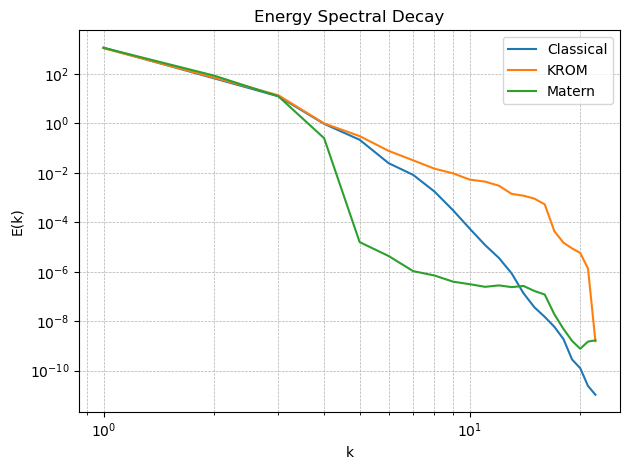

In [144]:
k = np.arange(1,23)
ref_line = k**(-5/3)
plt.loglog(k,compute_energy_spectrum(omega)[1:],label='Classical')
plt.loglog(k,KROM_spectrum,label='KROM')
plt.loglog(k,Matern_spectrum,label='Matern')
#plt.loglog(k, ref_line, 'k--', alpha=0.5, label=r'$k^{-5/3}$')
plt.title('Energy Spectral Decay')
plt.legend()
plt.xlabel('k')
plt.ylabel('E(k)')

plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

In [1162]:
rho_Matern = [0.22612600028514862,
0.2259751856327057,
0.22572369873523712,
0.22550371289253235,
0.22529229521751404,
0.22497573494911194,
0.22482873499393463,
0.22473767399787903,
0.22453515231609344,
0.22449633479118347,]

In [1756]:
rho_KROM = [0.2387048900127411,
0.10061559081077576,
0.07633821666240692,
0.0589682012796402,
0.0491902232170105,
0.05748173967003822,
0.06250298768281937,
0.0603519082069397,
0.0634969174861908,
0.06656837463378906]

In [3324]:
solutions_N = [0.24178780615329742,
0.1748596876859665,
0.09723357111215591,
0.10674495995044708,
0.08701614290475845,
0.09050458669662476,
0.0844883844256401,
0.08889049291610718,
0.0756608322262764,
0.06510065495967865]

In [3326]:
N_list = [
0.1748596876859665,
0.10674495995044708,
0.09050458669662476,
0.08889049291610718,
0.06510065495967865,
0.07710036635398865,
0.06482908874750137,
0.0723312646150589,
0.06995949149131775,
0.06662703305482864]

Text(0, 0.5, 'Relative Error')

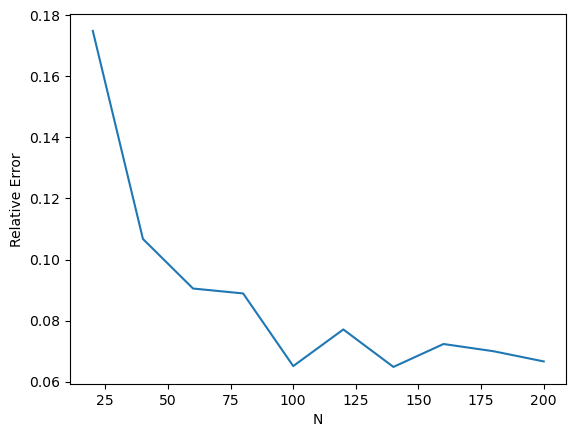

In [3327]:
plt.plot(20*np.arange(1,11),N_list)
plt.xlabel(r'N')
plt.ylabel('Relative Error')

In [3098]:
rho_KROM = [0.2387038916349411,
0.1324572116136551,
0.09891951084136963,
0.06928045302629471,
0.05671469122171402,
0.05651957914233208,
0.054682936519384384,
0.0556226409971714,
0.05868108570575714,
0.06002207472920418]

In [3276]:
rho_Matern = [0.23128072917461395,
0.2313086837530136,
0.23143768310546875,
0.23161602020263672,
0.2317463606595993,
0.23180313408374786,
0.23169775307178497,
0.231552854180336,
0.231511652469635,
0.23160454630851746]

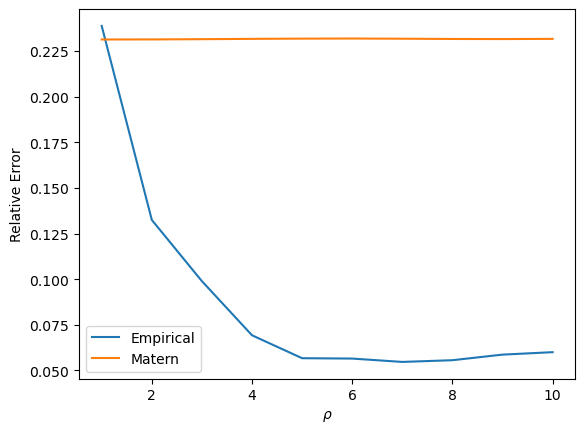

In [3328]:
plt.plot(np.arange(1,11),rho_KROM)
plt.plot(np.arange(1,11),rho_Matern)
plt.xlabel(r'$\rho$')
plt.ylabel('Relative Error')
plt.legend(['Empirical','Matern'])